In [1]:
import pandas as pd
import geopandas as geopd
import numpy as np
import utils

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"]  = 300
plt.rcParams.update({'font.size': 18})
plt.style.use('dark_background')

# This script analyzes the availability of flow timeseries data for catchments.
# It reads flow data from a CSV file, calculates the number of valid observations,
# and visualizes the availability over different decades.

In [2]:
@FuncFormatter
def date_formatter(x, pos):
    start_date = pd.to_datetime("1961-01-01")
    time = start_date + pd.Timedelta(days=x)
    label = f"{time.year - start_date.year}"
    return label

In [3]:
# Path to the flow data CSV file
src_path = '/path/to/discharge_spec.csv'
data = utils.read_daily_timeseries_csv(src_path)

In [5]:
# Calculate the number of valid observations for each gauge, as well as start and end years and the number of years
valid_counts = len(data) - data.isna().sum()
valid_counts = valid_counts.sort_values(ascending=False)
start_year = data.index[0].year
end_year = data.index[-1].year
year_count = end_year-start_year

gauge_count = len(data.columns)

xticks = [tick for tick in range(0, gauge_count + gauge_count//4, gauge_count//4)]
xlabels = [str(label) for label in range(0, 101, 25)]
cm_conversion = 1/2.54 

In [6]:
# Create a DataFrame for valid counts
counts = pd.DataFrame(valid_counts)
counts = counts.rename(columns={0:'total_count'}, errors='raise')

decade_starts = [year for year in range(start_year, end_year - 10, 10)]
decade_ends = [year + 9 for year in decade_starts]

decade_starts = list(map(str, decade_starts))
decade_ends = list(map(str, decade_ends))

decades = list(zip(decade_starts, decade_ends))

# Calculate the percentage of valid observations for each decade
for decade in decades:
    decade_data = data.loc[decade[0]:decade[1]]
    decade_portion = ((len(decade_data) - decade_data.isna().sum()) / len(decade_data)) * 100
    decade_portion = decade_portion.sort_values(ascending=False)
    
    name = f"{decade[0]}-{decade[1]}"
    counts[name] = list(decade_portion)

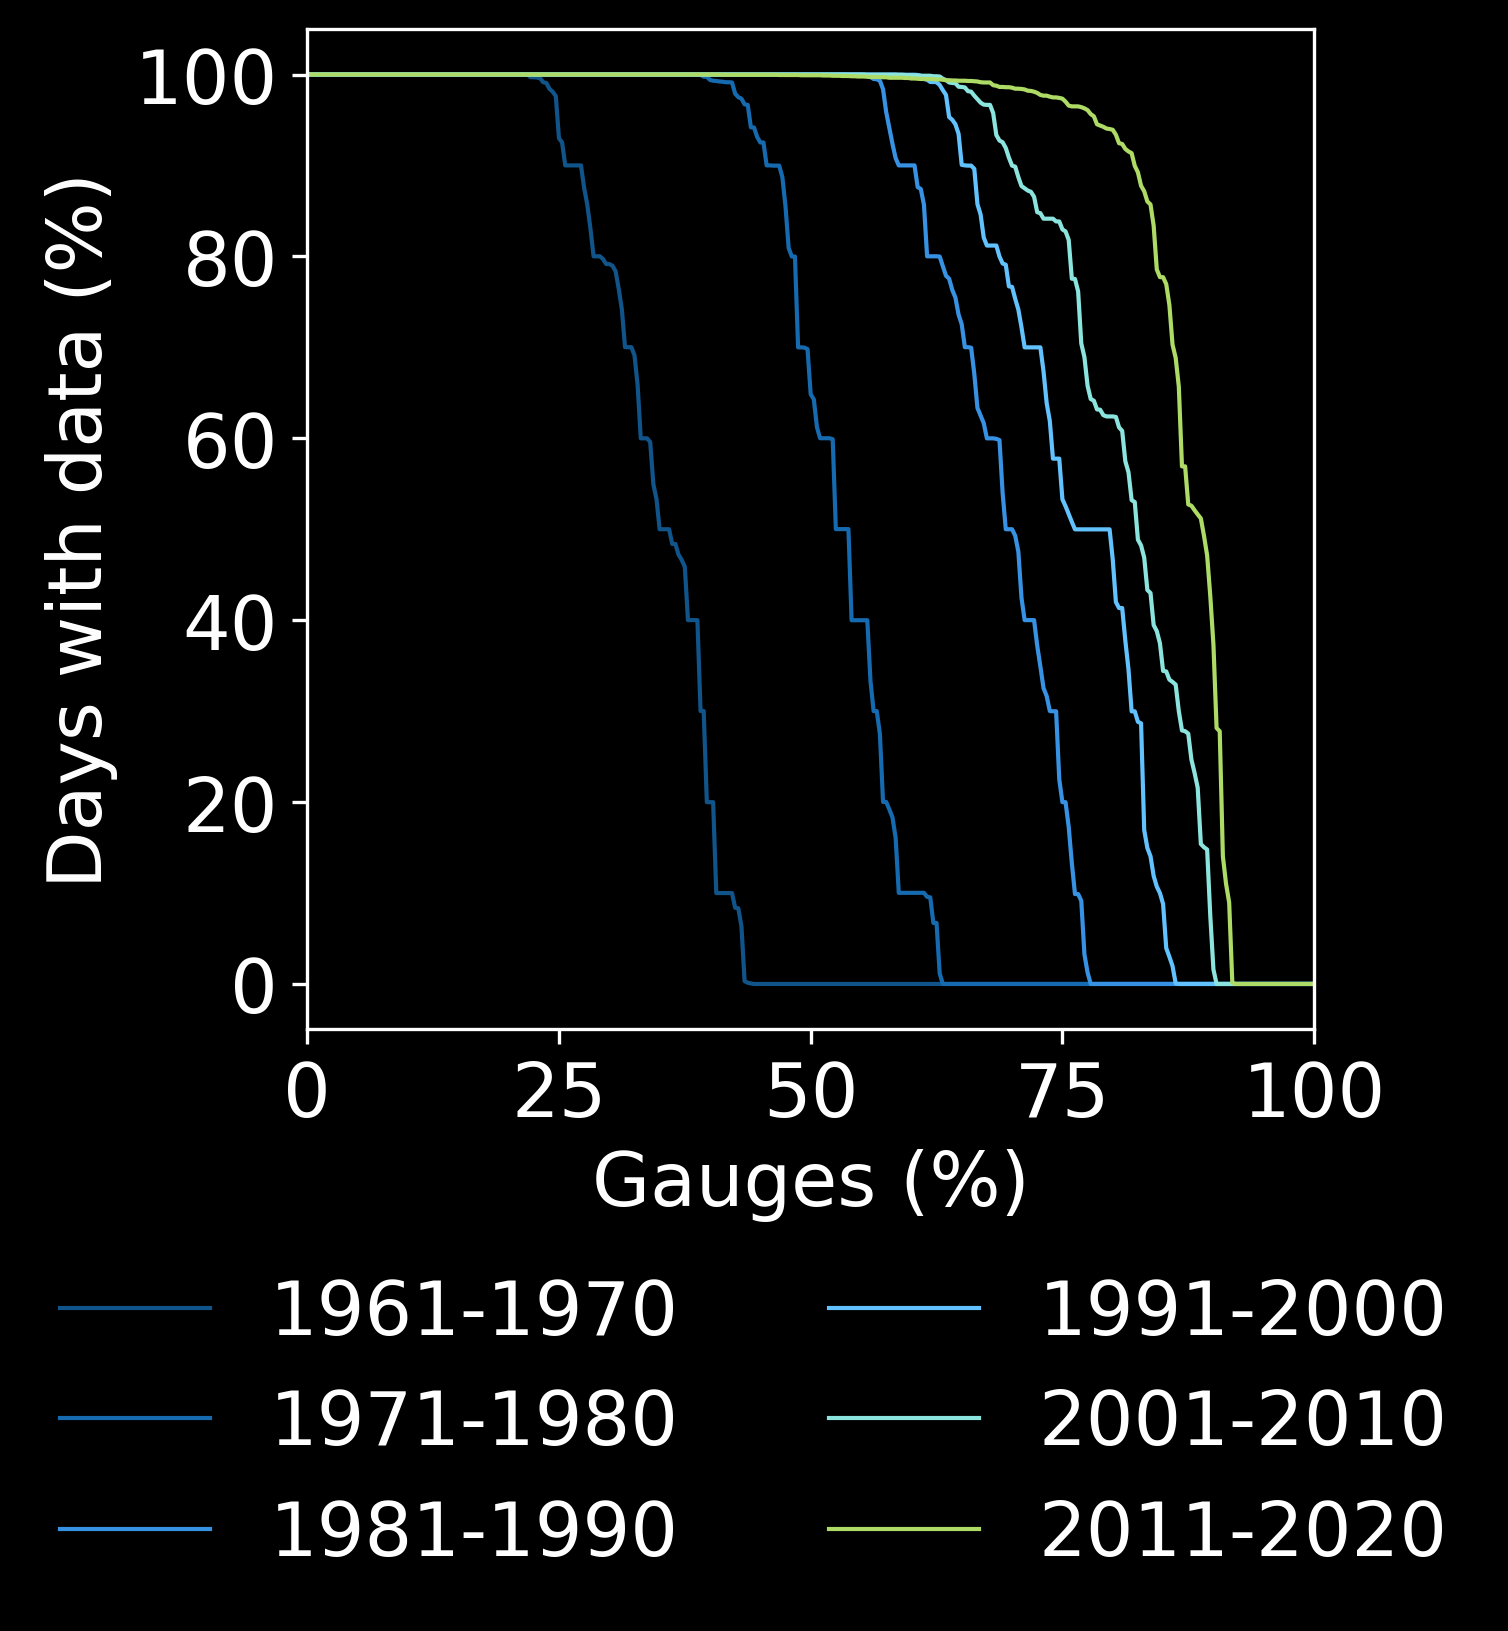

In [9]:
# Plot the data availability over different decades

cmap = LinearSegmentedColormap.from_list('DIWA_6', ['#11548a', '#1770b8', '#4ca9ff', '#83e7fc', '#addb65'])

plt_data = counts.iloc[:, -6:]
plt_data = plt_data.reset_index(drop=True)
ax = plt_data.plot(legend=True, xlim=(0, gauge_count), cmap=cmap, figsize=(11*cm_conversion, 11*cm_conversion), linewidth=1)
legend = ax.legend(bbox_to_anchor=(1.2, -0.18), ncol=2)
legend.get_frame().set_edgecolor('#000000')

ax.set_ylabel('Days with data (%)')
ax.set_xticks(xticks, xlabels)
ax.set_xlabel('Gauges (%)')


# Save the plot
dst_path = "path/to/flow_availability.png"
plt.savefig(dst_path, dpi=300, transparent=True, bbox_inches='tight')

In [76]:
# Calculate the total number of years of data for each gauge
total = counts[['total_count']].copy()
total['timeseries_length_y'] = total['total_count'] / 365.25
total = total.round(decimals=2)

# Read the gauge data and join the timeseries length
gauge_path = '/path/to/CAMELS-FI flow gauges.gpkg'
gauges = geopd.read_file(gauge_path, layer='attributes_v1')
gauges = gauges.set_index('Paikka_Id')
gauges = gauges.join(total['timeseries_length_y'])

<Axes: >

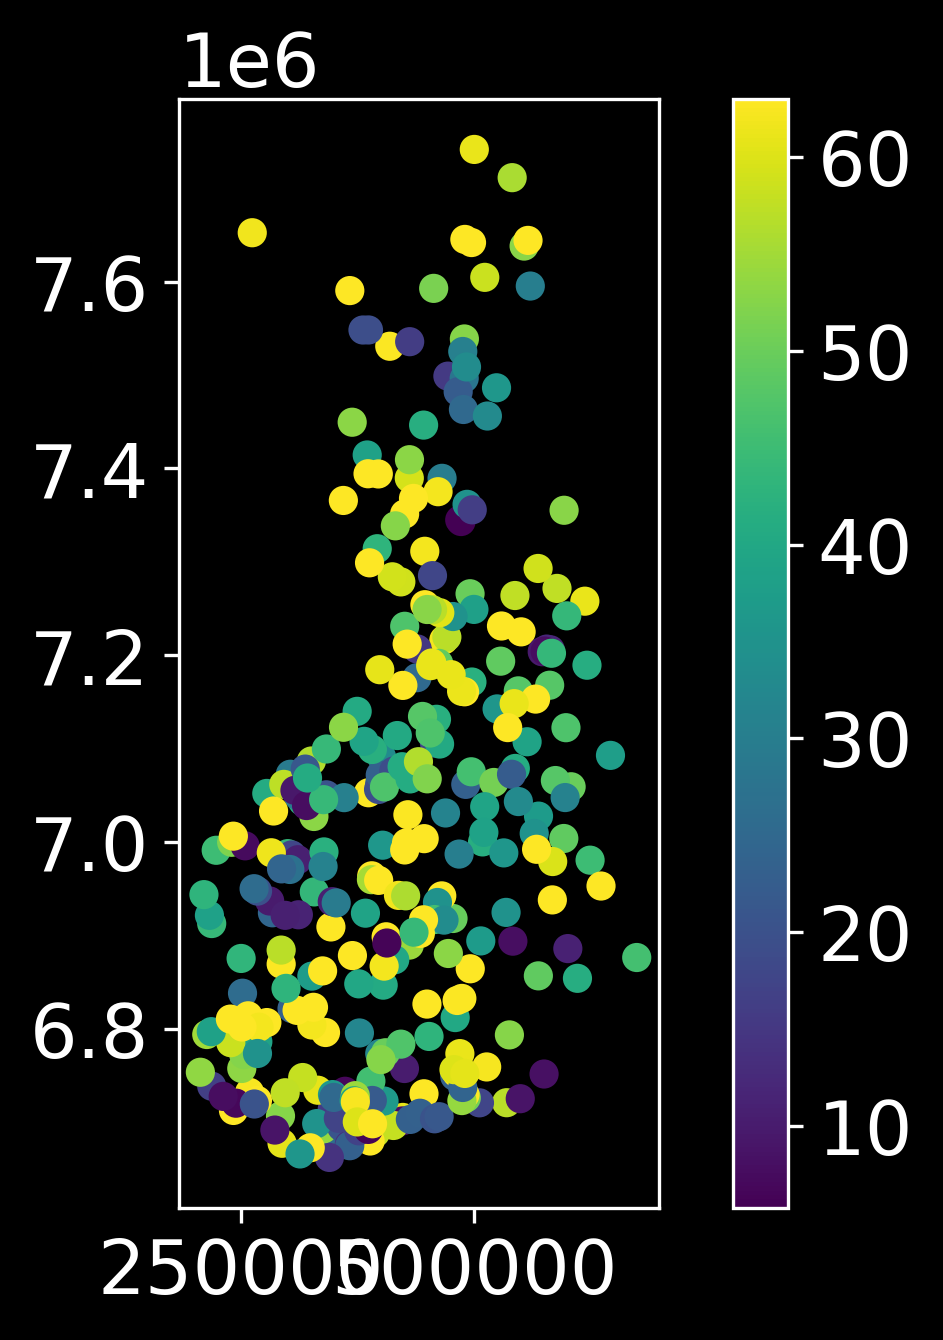

In [73]:
# Plot the timeseries length for each gauge
gauges.plot('timeseries_length', legend=True)

In [80]:
# Save the updated gauge data to a GeoPackage
gauges.to_file(gauge_path, driver='GPKG', layer='attributes_v1')